In [1]:
import networkx as nx
import pandas as pd
from node2vec import Node2Vec
from sklearn.model_selection import train_test_split
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import copy
from tqdm.auto import tqdm
print('setup complete')

setup complete


In [2]:
torch.manual_seed(100)
torch.set_num_threads(1)
np.random.seed(100)
RANDOM_STATE = 42

In [3]:
fb_friends_data = pd.read_csv("../data/interim/fb_friends.csv")
display(fb_friends_data)

friends_list = list(zip(fb_friends_data["user_a"], fb_friends_data["user_b"]))
print(friends_list)

friends_set = set(friends_list)

,Unnamed: 0,user_a,user_b
0,0,0,512
1,1,0,263
2,2,0,525
3,3,0,285
4,4,0,543
...,...,...,...
6413,6424,510,737
6414,6425,510,763
6415,6426,255,566
6416,6427,255,605


[(0, 512), (0, 263), (0, 525), (0, 285), (0, 543), (0, 806), (0, 817), (0, 824), (0, 341), (0, 600), (0, 104), (0, 107), (0, 108), (0, 371), (0, 632), (0, 687), (0, 208), (0, 744), (0, 491), (256, 524), (256, 532), (256, 818), (256, 838), (256, 373), (256, 421), (256, 706), (256, 486), (512, 790), (512, 538), (512, 809), (512, 560), (512, 820), (512, 580), (512, 839), (512, 631), (512, 690), (512, 700), (512, 728), (768, 838), (1, 537), (1, 43), (1, 345), (1, 390), (1, 412), (1, 420), (257, 514), (257, 534), (257, 545), (257, 816), (257, 565), (257, 574), (257, 578), (257, 331), (257, 346), (257, 359), (257, 621), (257, 659), (257, 444), (257, 707), (257, 721), (513, 519), (513, 544), (513, 590), (513, 653), (513, 663), (2, 817), (2, 354), (2, 140), (2, 666), (2, 686), (2, 720), (2, 502), (258, 775), (258, 532), (258, 792), (258, 302), (258, 561), (258, 590), (514, 534), (514, 578), (514, 659), (514, 679), (514, 721), (770, 824), (3, 521), (3, 23), (3, 49), (3, 817), (3, 90), (3, 357),

# SMS graph

In [4]:
sms_data = pd.read_csv('../data/interim/sms.csv', index_col=0)
sms_data = sms_data.astype({'sender': 'int', 'recipient': 'int'})

# Facebook friendship is undirected, so represent each relationship once.
sms_data['user_a'] = sms_data[['sender', 'recipient']].min(axis=1)
sms_data['user_b'] = sms_data[['sender', 'recipient']].max(axis=1)

sms_relationships = (
    sms_data.groupby(['user_a', 'user_b'])
    .size()
    .rename('total_texts')
    .reset_index()
)

display(sms_relationships.head())
print(f"Raw SMS records: {len(sms_data):,}")
print(f"Unique SMS relationships: {len(sms_relationships):,}")

,user_a,user_b,total_texts
0,0,208,4
1,0,512,132
2,1,345,3
3,3,49,75
4,3,217,6


Raw SMS records: 24,333
Unique SMS relationships: 697


Text(0.5, 0, 'pairs')

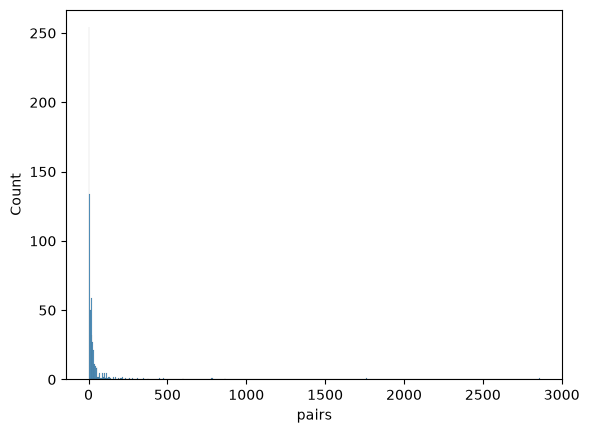

In [5]:
sns.histplot(x=sms_relationships['total_texts'])
plt.xlabel('pairs')

In [6]:
sms_relationships["node2vec_weight"] = np.log1p(sms_relationships["total_texts"])
sms_relationships.head()


,user_a,user_b,total_texts,node2vec_weight
0,0,208,4,1.609438
1,0,512,132,4.890349
2,1,345,3,1.386294
3,3,49,75,4.330733
4,3,217,6,1.945910


In [7]:
G_sms = nx.Graph()

for row in sms_relationships.itertuples(index=False):
    G_sms.add_edge(
        int(row.user_a),
        int(row.user_b),
        weight=float(row.node2vec_weight),
        total_texts=float(row.total_texts),
    )

# Keep G as the SMS graph for the Node2Vec code below.
G = G_sms
edges = list(
    sms_relationships[['user_a', 'user_b']]
    .itertuples(index=False, name=None)
)

print(edges[:3])

[(0, 208), (0, 512), (1, 345)]


In [8]:
print(f"SMS graph nodes: {G_sms.number_of_nodes():,}")
print(f"SMS graph relationships: {G_sms.number_of_edges():,}")
print(f"Total texts stored on edges: {sum(nx.get_edge_attributes(G_sms, 'total_texts').values()):,}")

SMS graph nodes: 568
SMS graph relationships: 697
Total texts stored on edges: 24,333.0


In [9]:
node2vec = Node2Vec(
    G_sms,
    dimensions=128,
    walk_length=30,
    num_walks=200,
    workers=1,
    weight_key='weight',
    seed=RANDOM_STATE,
    p=1.0,
    q=2.0
    
)  # tune p and q

node2vec_model = node2vec.fit(window=10, min_count=1)


concat_pairs = []
product_pairs = []  # hadamard product, element-wise interaction
for user_a, user_b in edges:
    u = node2vec_model.wv[str(user_a)]
    v = node2vec_model.wv[str(user_b)]
    label = int((user_a, user_b) in friends_set)

    concat_pairs.append([np.concatenate([u, v]), label])
    product_pairs.append([u * v, label])

print(f"Pair embeddings created: {len(concat_pairs):,}")

Computing transition probabilities:   0%|          | 0/568 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [00:02<00:00, 79.89it/s]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Pair embeddings created: 697


## Concat MLP

In [10]:
class ConcatMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = nn.Linear(256, 128)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(128, 64)
        self.output_layer = nn.Linear(64, 1)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.output_layer(x) # will use BCEWithLogitsLoss, don't need final sigmoid
        return x
    

In [11]:
temp = pd.DataFrame(columns=["embeddings", "is_friends"], data=concat_pairs)
temp.head()

,embeddings,is_friends
0,"[-0.56316495, -0.15060112, -0.14475124, 0.2841...",1
1,"[-0.56316495, -0.15060112, -0.14475124, 0.2841...",1
2,"[-0.093422055, 0.5504156, -0.5931576, -0.59888...",1
3,"[0.057247728, 0.26673532, 0.16202243, 0.188085...",1
4,"[0.057247728, 0.26673532, 0.16202243, 0.188085...",1


In [12]:
X = np.stack(temp["embeddings"].values).astype(np.float32)
y = temp["is_friends"].values.astype(np.float32)


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train_tensor = torch.from_numpy(X_train)

y_train_tensor = torch.from_numpy(y_train).view(-1, 1)

X_val_tensor = torch.from_numpy(X_val)
y_val_tensor = torch.from_numpy(y_val).view(-1, 1)

# create the Dataset and DataLoader strictly for the TRAINING split
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


In [13]:

model = ConcatMLP()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 300

# History
train_losses = []
val_losses = []
best_val_loss = float("inf")
best_state = None

print("Training started...")
print(f"{'=' * 50}\n")

for epoch in range(epochs):
    # ---- Training phase ----
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        pred = model(X_batch)
        loss = criterion(pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    # sample-weighted average
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # ---- Validation phase ----
    model.eval()
    with torch.no_grad():
        
        val_pred = model(X_val_tensor)
        val_loss = criterion(val_pred, y_val_tensor)
        val_losses.append(val_loss.item())
        
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_state = copy.deepcopy(model.state_dict())

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch + 1:3d}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {val_loss.item():.4f}"
        )

print(f"\n{'=' * 50}")
print("Training completed!")
print(f"Best val loss: {best_val_loss:.4f}")
model.load_state_dict(best_state)

Training started...

Epoch  20, Train Loss: 0.0992, Val Loss: 0.9702
Epoch  40, Train Loss: 0.0411, Val Loss: 1.3665
Epoch  60, Train Loss: 0.0159, Val Loss: 1.5864
Epoch  80, Train Loss: 0.0141, Val Loss: 1.6133
Epoch 100, Train Loss: 0.0327, Val Loss: 1.6259
Epoch 120, Train Loss: 0.0082, Val Loss: 1.7475
Epoch 140, Train Loss: 0.0168, Val Loss: 1.8440
Epoch 160, Train Loss: 0.0199, Val Loss: 1.6736
Epoch 180, Train Loss: 0.0625, Val Loss: 2.0121
Epoch 200, Train Loss: 0.0054, Val Loss: 1.7059
Epoch 220, Train Loss: 0.0054, Val Loss: 1.7850
Epoch 240, Train Loss: 0.0073, Val Loss: 1.8094
Epoch 260, Train Loss: 0.0026, Val Loss: 1.9494
Epoch 280, Train Loss: 0.0014, Val Loss: 2.2071
Epoch 300, Train Loss: 0.0035, Val Loss: 1.7240

Training completed!
Best val loss: 0.4649


<All keys matched successfully>

In [14]:
# Evaluate the trained MLP on the held-out validation split.
model.eval()
with torch.no_grad():
    val_logits = model(X_val_tensor).squeeze(1)
    val_probabilities = torch.sigmoid(val_logits).cpu().numpy()

y_val_true = y_val_tensor.squeeze(1).cpu().numpy().astype(int)
y_val_pred = (val_probabilities >= 0.5).astype(int)

accuracy = accuracy_score(y_val_true, y_val_pred)
precision = precision_score(y_val_true, y_val_pred, zero_division=0)
recall = recall_score(y_val_true, y_val_pred, zero_division=0)
auc_roc = roc_auc_score(y_val_true, val_probabilities)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")


Accuracy:  0.8286
Precision: 0.8286
Recall:    1.0000
AUC-ROC:   0.5295


## Concat XGBoost

In [15]:
'''model = xgb.XGBClassifier(
    n_estimators=1000,  # Number of boosting rounds (trees)
    max_depth=6,  # Maximum tree depth
    learning_rate=0.1,  # Step size shrinkage (eta)
    subsample=0.8,  # Fraction of samples to train each tree
    early_stopping_rounds=50,
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train)
predictions = model.predict(X_val)


accuracy = accuracy_score(y_val_true, predictions)
precision = precision_score(y_val_true, predictions, zero_division=0)
recall = recall_score(y_val_true, predictions, zero_division=0)
auc_roc = roc_auc_score(y_val_true, predictions)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")
'''

'model = xgb.XGBClassifier(\n    n_estimators=1000,  # Number of boosting rounds (trees)\n    max_depth=6,  # Maximum tree depth\n    learning_rate=0.1,  # Step size shrinkage (eta)\n    subsample=0.8,  # Fraction of samples to train each tree\n    early_stopping_rounds=50,\n    random_state=RANDOM_STATE,\n)\n\nmodel.fit(X_train, y_train)\npredictions = model.predict(X_val)\n\n\naccuracy = accuracy_score(y_val_true, predictions)\nprecision = precision_score(y_val_true, predictions, zero_division=0)\nrecall = recall_score(y_val_true, predictions, zero_division=0)\nauc_roc = roc_auc_score(y_val_true, predictions)\n\nprint(f"Accuracy:  {accuracy:.4f}")\nprint(f"Precision: {precision:.4f}")\nprint(f"Recall:    {recall:.4f}")\nprint(f"AUC-ROC:   {auc_roc:.4f}")\n'

## Hadamard Product MLP

In [16]:
class ProductMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = nn.Linear(128, 64)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(64,64)
        self.output_layer = nn.Linear(64, 1)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.output_layer(x) # will use BCEWithLogitsLoss, don't need final sigmoid
        return x
    

In [17]:
temp = pd.DataFrame(columns=["embeddings", "is_friends"], data=product_pairs)
temp.head()

,embeddings,is_friends
0,"[0.3421231, 0.032978225, 0.05511443, 0.0021077...",1
1,"[0.28948003, -0.00511455, 0.0026740103, 0.0455...",1
2,"[0.0038991321, 0.33137122, 0.34624746, 0.36470...",1
3,"[0.0059002265, 0.03952396, 0.025449533, 0.0104...",1
4,"[0.0057612304, -0.032044332, -0.011255444, 0.0...",1


In [18]:
X = np.stack(temp["embeddings"].values).astype(np.float32)
y = temp["is_friends"].values.astype(np.float32)


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train_tensor = torch.from_numpy(X_train)

y_train_tensor = torch.from_numpy(y_train).view(-1, 1)

X_val_tensor = torch.from_numpy(X_val)
y_val_tensor = torch.from_numpy(y_val).view(-1, 1)

# create the Dataset and DataLoader strictly for the TRAINING split
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


In [19]:

model = ProductMLP()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 300

# History
train_losses = []
val_losses = []
best_val_loss = float("inf")

print("Training started...")
print(f"{'=' * 50}\n")

for epoch in range(epochs):
    # ---- Training phase ----
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        pred = model(X_batch)
        loss = criterion(pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    # sample-weighted average
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # ---- Validation phase ----
    model.eval()
    with torch.no_grad():
        # Pass the TENSOR validation data, not the NumPy arrays
        val_pred = model(X_val_tensor)
        val_loss = criterion(val_pred, y_val_tensor)
        val_losses.append(val_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            # E.g., torch.save(model.state_dict(), 'best_model.pth')

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch + 1:3d}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {val_loss.item():.4f}"
        )

print(f"\n{'=' * 50}")
print("Training completed!")
print(f"Best val loss: {best_val_loss:.4f}")


Training started...

Epoch  20, Train Loss: 0.2324, Val Loss: 0.6117
Epoch  40, Train Loss: 0.1077, Val Loss: 1.0287
Epoch  60, Train Loss: 0.0629, Val Loss: 1.3289
Epoch  80, Train Loss: 0.0361, Val Loss: 1.6363
Epoch 100, Train Loss: 0.0335, Val Loss: 2.1047
Epoch 120, Train Loss: 0.0151, Val Loss: 2.1390
Epoch 140, Train Loss: 0.0129, Val Loss: 2.3955
Epoch 160, Train Loss: 0.0506, Val Loss: 2.3598
Epoch 180, Train Loss: 0.0109, Val Loss: 2.5396
Epoch 200, Train Loss: 0.0270, Val Loss: 2.6551
Epoch 220, Train Loss: 0.0056, Val Loss: 2.8456
Epoch 240, Train Loss: 0.0043, Val Loss: 2.9372
Epoch 260, Train Loss: 0.0110, Val Loss: 3.1411
Epoch 280, Train Loss: 0.0030, Val Loss: 3.1022
Epoch 300, Train Loss: 0.0071, Val Loss: 2.9330

Training completed!
Best val loss: 0.4569


In [20]:
# Evaluate the trained MLP on the held-out validation split.
model.eval()
with torch.no_grad():
    val_logits = model(X_val_tensor).squeeze(1)
    val_probabilities = torch.sigmoid(val_logits).cpu().numpy()

y_val_true = y_val_tensor.squeeze(1).cpu().numpy().astype(int)
y_val_pred = (val_probabilities >= 0.5).astype(int)

accuracy = accuracy_score(y_val_true, y_val_pred)
precision = precision_score(y_val_true, y_val_pred, zero_division=0)
recall = recall_score(y_val_true, y_val_pred, zero_division=0)
auc_roc = roc_auc_score(y_val_true, val_probabilities)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")


Accuracy:  0.7357
Precision: 0.8319
Recall:    0.8534
AUC-ROC:   0.5546


# Calls Graph

In [21]:
calls_data = pd.read_csv("../data/interim/calls.csv")
display(calls_data.head())

calls_data = calls_data.astype({"caller": "int", "callee": "int"})


,Unnamed: 0,timestamp,caller,callee,duration
0,0,184,300,301,121
1,1,3920,512,299,670
2,2,5623,301,300,504
3,4,15466,512,0,5
4,5,15497,512,0,28


In [22]:
calls_data = pd.read_csv('../data/interim/calls.csv', index_col=0)
calls_data = calls_data.astype({'caller': 'int', 'callee': 'int'})

# Aggregate both call directions into one undirected relationship.
calls_data['user_a'] = calls_data[['caller', 'callee']].min(axis=1)
calls_data['user_b'] = calls_data[['caller', 'callee']].max(axis=1)

call_relationships = (
    calls_data.groupby(['user_a', 'user_b'])
    .agg(
        total_calls=('duration', 'size'),
        total_call_duration=('duration', 'sum'),
    )
    .reset_index()
)

display(call_relationships.head())
print(f"Raw call records: {len(calls_data):,}")
print(f"Unique call relationships: {len(call_relationships):,}")

,user_a,user_b,total_calls,total_call_duration
0,0,208,4,201
1,0,512,5,55
2,3,48,2,39
3,3,49,6,291
4,3,357,7,104


Raw call records: 3,234
Unique call relationships: 605


<Axes: xlabel='total_call_duration', ylabel='Count'>

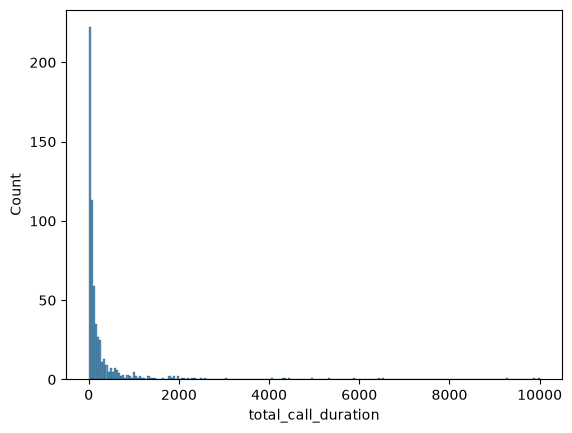

In [23]:
sns.histplot(x=call_relationships['total_call_duration'])

In [24]:
# Zero-duration relationships cannot define weighted Node2Vec transitions.
# Retain them in call_relationships for auditing, but exclude them from G_calls.
call_graph_relationships = call_relationships.loc[
    call_relationships['total_call_duration'].gt(0)
].copy()
call_graph_relationships['node2vec_weight'] = np.log1p(
    call_graph_relationships['total_call_duration']
)

print(f"Zero-duration relationships excluded: {len(call_relationships) - len(call_graph_relationships):,}")
display(call_graph_relationships.head())


Zero-duration relationships excluded: 37


,user_a,user_b,total_calls,total_call_duration,node2vec_weight
0,0,208,4,201,5.308268
1,0,512,5,55,4.025352
2,3,48,2,39,3.688879
3,3,49,6,291,5.676754
4,3,357,7,104,4.653960


In [25]:
G_calls = nx.Graph()

for row in call_graph_relationships.itertuples(index=False):
    G_calls.add_edge(
        int(row.user_a),
        int(row.user_b),
        weight=float(row.node2vec_weight),
        total_call_duration=float(row.total_call_duration),
        total_calls=int(row.total_calls),
    )

print(f"Calls graph nodes: {G_calls.number_of_nodes():,}")
print(f"Calls graph relationships: {G_calls.number_of_edges():,}")
print(f"Total raw duration stored on edges: {sum(nx.get_edge_attributes(G_calls, 'total_call_duration').values()):,.0f}")

Calls graph nodes: 504
Calls graph relationships: 568
Total raw duration stored on edges: 204,813


In [26]:
node2vec = Node2Vec(
    G_calls,
    dimensions=128,
    walk_length=30,
    num_walks=200,
    workers=1,
    weight_key="weight",
    p=1.0,
    q=2.0,
    seed=RANDOM_STATE,
)  # tune p and q

node2vec_model = node2vec.fit(window=10, min_count=1)


call_concat_pairs = []
call_product_pairs = []  # hadamard product, element-wise interaction
call_edges = list(
    call_graph_relationships[['user_a', 'user_b']]
    .itertuples(index=False, name=None)
)

for user_a, user_b in call_edges:
    u = node2vec_model.wv[str(user_a)]
    v = node2vec_model.wv[str(user_b)]
    label = int((user_a, user_b) in friends_set)

    call_concat_pairs.append([np.concatenate([u, v]), label])
    call_product_pairs.append([u * v, label])

print(f"Call pair embeddings created: {len(call_concat_pairs):,}")


Computing transition probabilities:   0%|          | 0/504 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [00:02<00:00, 89.44it/s]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Call pair embeddings created: 568


## Shared graph-pair model helpers

These helpers preserve the SMS pipeline structure while using stratified splits, early stopping for the MLP, probability-based ROC AUC, and class balancing when Facebook friendships are the minority.

In [27]:
import copy


class TqdmXGBoostCallback(xgb.callback.TrainingCallback):
    def __init__(self, total_rounds, description):
        self.progress_bar = tqdm(
            total=total_rounds,
            desc=description,
            unit='tree',
        )

    def after_iteration(self, model, epoch, evals_log):
        self.progress_bar.update(1)
        if evals_log:
            dataset = next(iter(evals_log.values()))
            metric_name, metric_values = next(iter(dataset.items()))
            self.progress_bar.set_postfix(
                {metric_name: f'{metric_values[-1]:.4f}'}
            )
        return False

    def after_training(self, model):
        self.progress_bar.close()
        return model


class GraphPairMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.network(x)


def pair_records_to_arrays(pair_records):
    X = np.stack([record[0] for record in pair_records]).astype(np.float32)
    y = np.asarray([record[1] for record in pair_records], dtype=np.float32)
    return X, y


def metric_row(y_true, y_pred, y_probability, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_true, y_probability),
    }


def run_pair_mlp(pair_records, model_name, max_epochs=75, patience=8):
    X, y = pair_records_to_arrays(pair_records)
    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    X_train_tensor = torch.from_numpy(X_train)
    y_train_tensor = torch.from_numpy(y_train).view(-1, 1)
    X_val_tensor = torch.from_numpy(X_val)
    y_val_tensor = torch.from_numpy(y_val).view(-1, 1)
    train_loader = DataLoader(
        TensorDataset(X_train_tensor, y_train_tensor),
        batch_size=256,
        shuffle=True,
    )

    torch.manual_seed(RANDOM_STATE)
    pair_model = GraphPairMLP(X.shape[1])
    positive_count = y_train.sum()
    negative_count = len(y_train) - positive_count
    positive_weight = max(1.0, negative_count / positive_count)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([positive_weight], dtype=torch.float32)
    )
    optimizer = torch.optim.Adam(
        pair_model.parameters(), lr=1e-3, weight_decay=1e-4
    )

    best_loss = float('inf')
    best_state = None
    epochs_without_improvement = 0
    history = []

    with tqdm(
        range(max_epochs), desc=model_name, unit='epoch'
    ) as epoch_progress:
        for epoch in epoch_progress:
            pair_model.train()
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                loss = criterion(pair_model(X_batch), y_batch)
                loss.backward()
                optimizer.step()

            pair_model.eval()
            with torch.no_grad():
                validation_loss = criterion(
                    pair_model(X_val_tensor), y_val_tensor
                ).item()
            history.append(validation_loss)
            epoch_progress.set_postfix(
                val_loss=f'{validation_loss:.4f}',
                best=f'{min(best_loss, validation_loss):.4f}',
            )

            if validation_loss < best_loss - 1e-4:
                best_loss = validation_loss
                best_state = copy.deepcopy(pair_model.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement >= patience:
                    epoch_progress.set_description(
                        f'{model_name} (early stopped)'
                    )
                    break

    pair_model.load_state_dict(best_state)
    pair_model.eval()
    with torch.no_grad():
        probabilities = torch.sigmoid(
            pair_model(X_val_tensor).squeeze(1)
        ).numpy()
    predictions = (probabilities >= 0.5).astype(int)
    metrics = metric_row(
        y_val.astype(int), predictions, probabilities, model_name
    )
    return pair_model, metrics, history


def run_pair_xgboost(pair_records, model_name):
    X, y = pair_records_to_arrays(pair_records)
    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y,
    )
    positive_count = y_train.sum()
    negative_count = len(y_train) - positive_count
    scale_pos_weight = max(1.0, negative_count / positive_count)
    boosting_rounds = 150
    progress_callback = TqdmXGBoostCallback(
        boosting_rounds, f'{model_name} boosting'
    )
    pair_model = xgb.XGBClassifier(
        n_estimators=boosting_rounds,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=1,
        callbacks=[progress_callback],
    )
    pair_model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    probabilities = pair_model.predict_proba(X_val)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    metrics = metric_row(
        y_val.astype(int), predictions, probabilities, model_name
    )
    return pair_model, metrics


## Calls: Concat MLP, Concat XGBoost, and Hadamard MLP

In [28]:
call_concat_mlp, call_concat_mlp_metrics, call_concat_history = run_pair_mlp(
    call_concat_pairs, 'Calls — Concat MLP'
)
call_concat_xgb, call_concat_xgb_metrics = run_pair_xgboost(
    call_concat_pairs, 'Calls — Concat XGBoost'
)
call_product_mlp, call_product_mlp_metrics, call_product_history = run_pair_mlp(
    call_product_pairs, 'Calls — Hadamard MLP'
)

call_model_comparison = pd.DataFrame(
    [
        call_concat_mlp_metrics,
        call_concat_xgb_metrics,
        call_product_mlp_metrics,
    ]
).set_index('Model')
display(call_model_comparison.round(4))

Calls — Concat MLP:   0%|          | 0/75 [00:00<?, ?epoch/s]

Calls — Concat XGBoost boosting:   0%|          | 0/150 [00:00<?, ?tree/s]

Calls — Hadamard MLP:   0%|          | 0/75 [00:00<?, ?epoch/s]

,Accuracy,Precision,Recall,AUC-ROC
Model,,,,
Calls — Concat MLP,0.8333,0.8627,0.9462,0.8116
Calls — Concat XGBoost,0.8509,0.8800,0.9462,0.8044
Calls — Hadamard MLP,0.8158,0.8158,1.0000,0.8408


# Proximity Graph

A proximity interaction is a valid participant-to-participant Bluetooth measurement with `rssi > -80`. Each unordered pair appears once, and its edge weight is the total number of qualifying measurements.

In [29]:
RSSI_THRESHOLD = -80
proximity_data = pd.read_csv(
    '../data/raw/bt_symmetric.csv',
    usecols=['# timestamp', 'user_a', 'user_b', 'rssi'],
)

proximity_interactions = proximity_data.loc[
    proximity_data['user_a'].ge(0)
    & proximity_data['user_b'].ge(0)
    & proximity_data['user_a'].ne(proximity_data['user_b'])
    & proximity_data['rssi'].gt(RSSI_THRESHOLD)
].copy()
proximity_interactions['pair_a'] = proximity_interactions[
    ['user_a', 'user_b']
].min(axis=1)
proximity_interactions['pair_b'] = proximity_interactions[
    ['user_a', 'user_b']
].max(axis=1)

proximity_relationships = (
    proximity_interactions.groupby(['pair_a', 'pair_b'])
    .size()
    .rename('total_interactions')
    .reset_index()
    .rename(columns={'pair_a': 'user_a', 'pair_b': 'user_b'})
)

display(proximity_relationships.head())
print(f"Qualifying RSSI measurements: {len(proximity_interactions):,}")
print(f"Unique proximity relationships: {len(proximity_relationships):,}")

,user_a,user_b,total_interactions
0,0,12,9
1,0,25,15
2,0,35,1
3,0,37,19
4,0,52,5


Qualifying RSSI measurements: 659,607
Unique proximity relationships: 31,758


In [30]:
G_proximity = nx.Graph()
for row in proximity_relationships.itertuples(index=False):
    G_proximity.add_edge(
        int(row.user_a),
        int(row.user_b),
        weight=float(row.total_interactions),
        total_interactions=int(row.total_interactions),
    )

proximity_edges = list(
    proximity_relationships[['user_a', 'user_b']]
    .itertuples(index=False, name=None)
)
print(f"Proximity graph nodes: {G_proximity.number_of_nodes():,}")
print(f"Proximity graph relationships: {G_proximity.number_of_edges():,}")
print(f"Total interactions stored on edges: {sum(nx.get_edge_attributes(G_proximity, 'total_interactions').values()):,}")

Proximity graph nodes: 675
Proximity graph relationships: 31,758
Total interactions stored on edges: 659,607


In [31]:
proximity_node2vec = Node2Vec(
    G_proximity,
    dimensions=128,
    walk_length=30,
    num_walks=100,
    workers=1,
    weight_key='weight',
    p=1.0,
    q=2.0,
    seed=RANDOM_STATE,
)
proximity_node2vec_model = proximity_node2vec.fit(
    window=10, min_count=1, seed=RANDOM_STATE
)

proximity_concat_pairs = []
proximity_product_pairs = []
for user_a, user_b in proximity_edges:
    u = proximity_node2vec_model.wv[str(user_a)]
    v = proximity_node2vec_model.wv[str(user_b)]
    label = int((user_a, user_b) in friends_set)
    proximity_concat_pairs.append([np.concatenate([u, v]), label])
    proximity_product_pairs.append([u * v, label])

print(f"Proximity pair embeddings created: {len(proximity_concat_pairs):,}")

Computing transition probabilities:   0%|          | 0/675 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 100/100 [00:09<00:00, 10.17it/s]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Proximity pair embeddings created: 31,758


## Proximity: Concat MLP, Concat XGBoost, and Hadamard MLP

In [32]:
proximity_concat_mlp, proximity_concat_mlp_metrics, proximity_concat_history = run_pair_mlp(
    proximity_concat_pairs, 'Proximity — Concat MLP'
)
proximity_concat_xgb, proximity_concat_xgb_metrics = run_pair_xgboost(
    proximity_concat_pairs, 'Proximity — Concat XGBoost'
)
proximity_product_mlp, proximity_product_mlp_metrics, proximity_product_history = run_pair_mlp(
    proximity_product_pairs, 'Proximity — Hadamard MLP'
)

proximity_model_comparison = pd.DataFrame(
    [
        proximity_concat_mlp_metrics,
        proximity_concat_xgb_metrics,
        proximity_product_mlp_metrics,
    ]
).set_index('Model')
display(proximity_model_comparison.round(4))

Proximity — Concat MLP:   0%|          | 0/75 [00:00<?, ?epoch/s]

Proximity — Concat XGBoost boosting:   0%|          | 0/150 [00:00<?, ?tree/s]

Proximity — Hadamard MLP:   0%|          | 0/75 [00:00<?, ?epoch/s]

,Accuracy,Precision,Recall,AUC-ROC
Model,,,,
Proximity — Concat MLP,0.8092,0.2673,0.7669,0.8663
Proximity — Concat XGBoost,0.8040,0.2426,0.6590,0.8161
Proximity — Hadamard MLP,0.8386,0.3017,0.7418,0.8627
